In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/oladimejiwilliams/energydata-complete/energydata_complete.csv


In [2]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/oladimejiwilliams/energydata-complete/energydata_complete.csv",header= 0,encoding= 'unicode_escape')

df['date'] = pd.to_datetime(df['date']) #very important to filter the data by days, months etc
df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.weekday      # 0 = Monday, 1 Tuesday etc
df['month'] = df['date'].dt.month

y = df['Appliances'] #dataset only column is appliances
X = df.drop(columns=['Appliances', 'date']) #dataset w/o the columns appliances and date

#1) SCALING
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import numpy as np

def eval_model(model):
    preds = model.predict(X_test)
    print("MAE :", mean_absolute_error(y_test, preds)) #average absolute difference between your model’s predictions and the actual values.
    print("RMSE:", np.sqrt(mean_squared_error(y_test, preds))) #average of squared differences between predictions and actual values->emphasizes big errors
    print("R²  :", r2_score(y_test, preds)) #how well the model’s predictions match the actual data. 1=perfect fit, <0=bad 
    print("\n")

In [4]:
print(f"\nXGBoost with 2000 trees")
    
xgboost = xgb.XGBRegressor( 
    n_estimators=2000,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
    )

    # Training
xgboost.fit(X_train, y_train)

eval_model(xgboost)


XGBoost with 2000 trees
MAE : 30.736156463623047
RMSE: 62.55121534403328
R²  : 0.6090117692947388




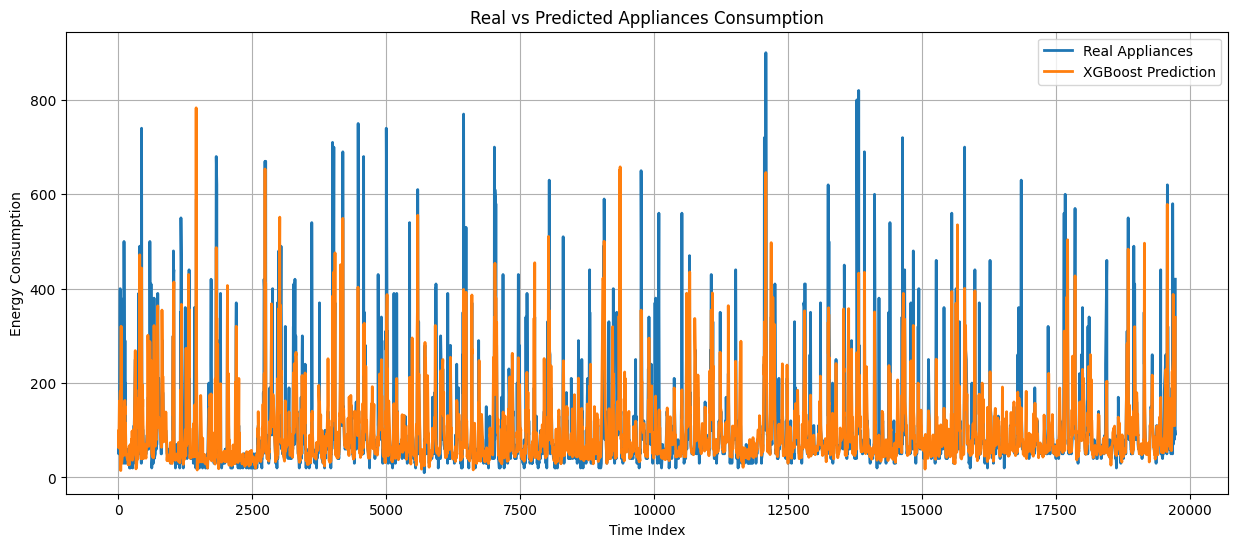

In [5]:
import matplotlib.pyplot as plt

# Predizioni del modello
y_pred = xgboost.predict(X_test)

# Creiamo un dataframe con valori reali e predetti
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

# Ordina per indice temporale
results = results.sort_index()

# Plot
plt.figure(figsize=(15,6))

plt.plot(
    results.index,
    results['Actual'],
    label='Real Appliances',
    linewidth=2
)

plt.plot(
    results.index,
    results['Predicted'],
    label='XGBoost Prediction',
    linewidth=2
)

plt.xlabel("Time Index")
plt.ylabel("Energy Consumption")
plt.title("Real vs Predicted Appliances Consumption")

plt.legend()
plt.grid(True)

plt.show()

Per vedere la differenza tra il vero consumo di appliances e il consumo predetto da xgboost uso **y_test e y_pred**
****XGBoost tende a smorzare i picchi****. ma in generale l'andamento è corretto. ****Il modello sembra riuscire a predirre correttamente un basso consumo di energia, da 0 a 200-400.**** Ma dopo 400 fa fatica a predirre i picchi di consumo in modo efficace.

L'asse x(Time index) va da 0 a 20 mila,perchè il dataset ha 19 700 righe, cioè sto usando l'indice del dataframe come asse x. 